In [1]:
import os, re, random, math
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score

## 1) Загрузка данных

In [2]:
def find_data_dir():
    roots = ["/kaggle/input", "/content", "."]
    for root in roots:
        if not os.path.isdir(root):
            continue
        for cur, _, files in os.walk(root):
            jpgs = [f for f in files if f.lower().endswith(".jpg")]
            if len(jpgs) >= 10:
                return cur
    return None

DATA_DIR = find_data_dir()
print("DATA_DIR =", DATA_DIR)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Не нашёл папку с jpg. Проверь, что датасет подключён, и укажи путь вручную."
    )

DATA_DIR = Path(DATA_DIR)
files = sorted(DATA_DIR.glob("*.jpg"))
print("Файлов:", len(files))
print("Пример:", files[0].name if files else None)

DATA_DIR = /kaggle/input/datasets/jangedoo/utkface-new/UTKFace
Файлов: 23708
Пример: 100_0_0_20170112213500903.jpg.chip.jpg


## 2) Парсинг лейблов из имени файла

Ожидаемый формат: `age_gender_race_date.jpg`  
- `age` — целое число (0..116)  
- `gender` — 0/1 (обычно 0=male, 1=female, но в разных версиях датасета встречаются вариации)  
- `race` — 0..4 (кодировка из UTKFace)


In [3]:
pat=re.compile(r"^(\d+)_(\d+)_(\d+)_([0-9]+)\.jpg(?:\.chip)?\.jpg$")

rows=[]
bad=0
for fp in files:
    m = pat.match(fp.name)
    if not m:
        bad += 1
        continue
    age = int(m.group(1))
    gender = int(m.group(2))
    race = int(m.group(3))
    date = m.group(4)
    rows.append((str(fp), age, gender, race, date))

df = pd.DataFrame(rows, columns=["path","age","gender","race","date"])
bad, df.shape

(5, (23703, 5))

In [4]:
df

,path,age,gender,race,date
0,/kaggle/input/datasets/jangedoo/utkface-new/UT...,100,0,0,20170112213500903
1,/kaggle/input/datasets/jangedoo/utkface-new/UT...,100,0,0,20170112215240346
2,/kaggle/input/datasets/jangedoo/utkface-new/UT...,100,1,0,20170110183726390
3,/kaggle/input/datasets/jangedoo/utkface-new/UT...,100,1,0,20170112213001988
4,/kaggle/input/datasets/jangedoo/utkface-new/UT...,100,1,0,20170112213303693
...,...,...,...,...,...
23698,/kaggle/input/datasets/jangedoo/utkface-new/UT...,9,1,3,20161220222856346
23699,/kaggle/input/datasets/jangedoo/utkface-new/UT...,9,1,3,20170104222949455
23700,/kaggle/input/datasets/jangedoo/utkface-new/UT...,9,1,4,20170103200637399
23701,/kaggle/input/datasets/jangedoo/utkface-new/UT...,9,1,4,20170103200814791


### Быстрая чистка / sanity-check

- фильтруем невалидный возраст (на практике иногда бывают странные файлы)
- gender/race оставим как есть, но отдельно посмотрим на значения


In [5]:
df = df[(df["age"]>=0) & (df["age"]<=116)].copy()
df["gender"].value_counts(), df["race"].value_counts(), df.shape

(gender
 0    12389
 1    11314
 Name: count, dtype: int64,
 race
 0    10077
 1     4525
 3     3975
 2     3434
 4     1692
 Name: count, dtype: int64,
 (23703, 5))

## 3) EDA: распределение возраста

Ключевое, что почти всегда видно на UTKFace:
- **дисбаланс по возрасту** (много 20–40, меньше детей и пожилых);
- хвосты (80+), редкие возраста → модели сложно учить стабильные паттерны;
- лейбл “возраст” шумный, т.к. это не паспортные данные, и часто возраст визуально неоднозначен.


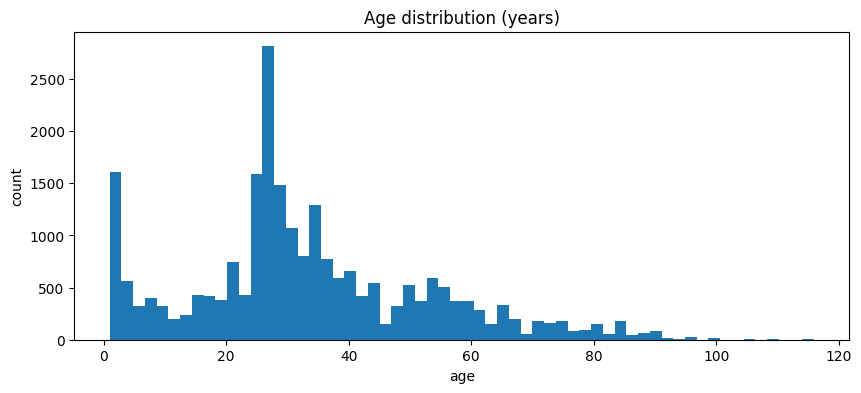

count    23703.000000
mean        33.300384
std         19.885956
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64

In [6]:
plt.figure(figsize=(10,4))
plt.hist(df["age"], bins=60)
plt.title("Age distribution (years)")
plt.xlabel("age"); plt.ylabel("count")
plt.show()

df["age"].describe()

### Возрастные группы (age bins)

Для “интерпретируемых” метрик (accuracy по группам, confusion matrix) заведём корзины.
Корзины можно поменять под ваш проект, но эти чаще всего удобны:
- 0–2 (infants)
- 3–12 (kids)
- 13–19 (teens)
- 20–29, 30–39, 40–49, 50–59, 60–69, 70–79
- 80+ (very old)

Почему так: детям (и подросткам) обычно сложнее, т.к. лицо быстро меняется по годам, и классы “ближе” друг к другу.


In [7]:
bins = [0,3,13,20,30,40,50,60,70,80,117]
labels = ["0-2","3-12","13-19","20-29","30-39","40-49","50-59","60-69","70-79","80+"]

df["age_bin"] = pd.cut(df["age"], bins=bins, right=False, labels=labels)
df["age_bin"].value_counts().reindex(labels)

age_bin
0-2      1605
3-12     1808
13-19    1180
20-29    7343
30-39    4536
40-49    2245
50-59    2298
60-69    1316
70-79     699
80+       673
Name: count, dtype: int64

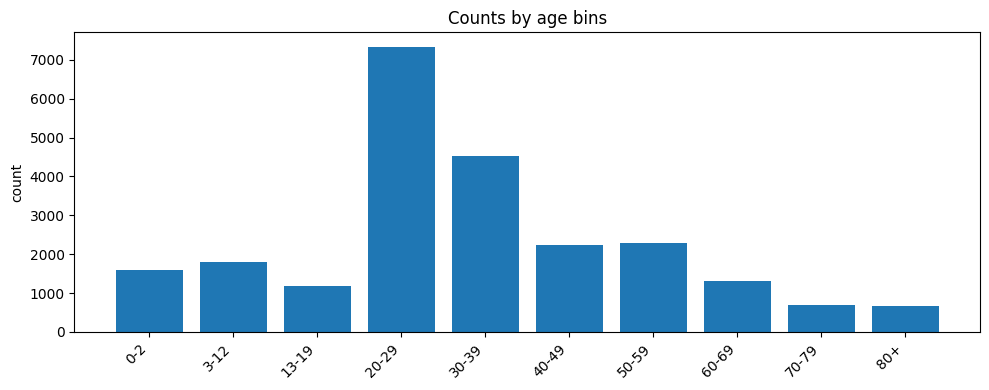

In [8]:
plt.figure(figsize=(10,4))
counts = df["age_bin"].value_counts().reindex(labels).fillna(0)
plt.bar(range(len(labels)), counts.values)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.title("Counts by age bins")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 4) EDA: gender / race и их связь с возрастом

Это нужно по двум причинам:
1) понять **смещение/дисбаланс** в данных (и потенциальный bias модели);
2) заранее придумать **стратификацию** при train/val split и мониторинг метрик по подгруппам.


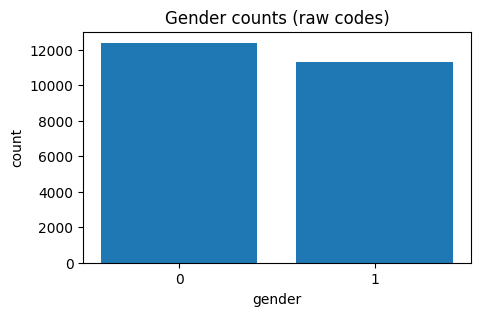

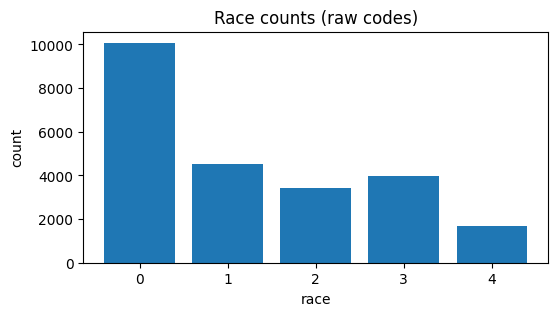

In [9]:
plt.figure(figsize=(5,3))
gvc = df["gender"].value_counts().sort_index()
plt.bar(gvc.index.astype(str), gvc.values)
plt.title("Gender counts (raw codes)")
plt.xlabel("gender"); plt.ylabel("count")
plt.show()

plt.figure(figsize=(6,3))
rvc = df["race"].value_counts().sort_index()
plt.bar(rvc.index.astype(str), rvc.values)
plt.title("Race counts (raw codes)")
plt.xlabel("race"); plt.ylabel("count")
plt.show()

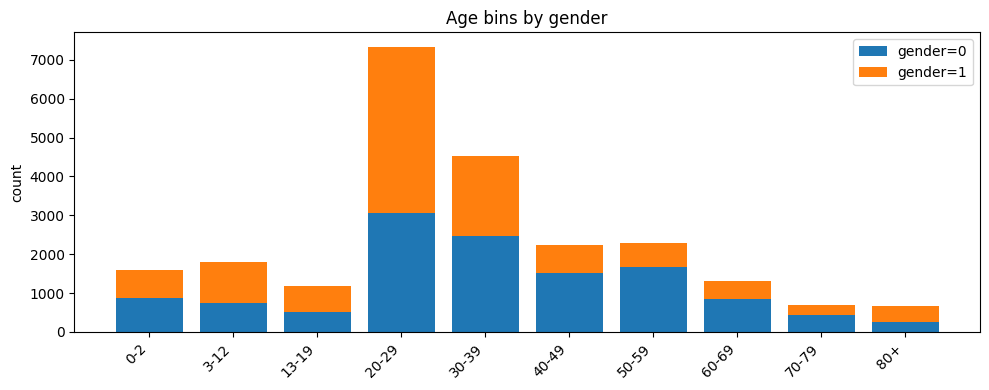

In [10]:
# age-bin vs gender (stacked)
ct = pd.crosstab(df["age_bin"], df["gender"]).reindex(labels).fillna(0)

plt.figure(figsize=(10,4))
bottom = np.zeros(len(ct))
for col in ct.columns:
    vals = ct[col].values
    plt.bar(range(len(ct)), vals, bottom=bottom, label=f"gender={col}")
    bottom += vals

plt.xticks(range(len(ct)), labels, rotation=45, ha="right")
plt.title("Age bins by gender")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

## 5) Визуальная проверка: примеры по возрастным группам

Это быстрый способ поймать:
- кривые обрезки, окклюзии, низкое качество;
- “невероятные” возраста (лейбл шумный);
- возможные дубликаты/серии.


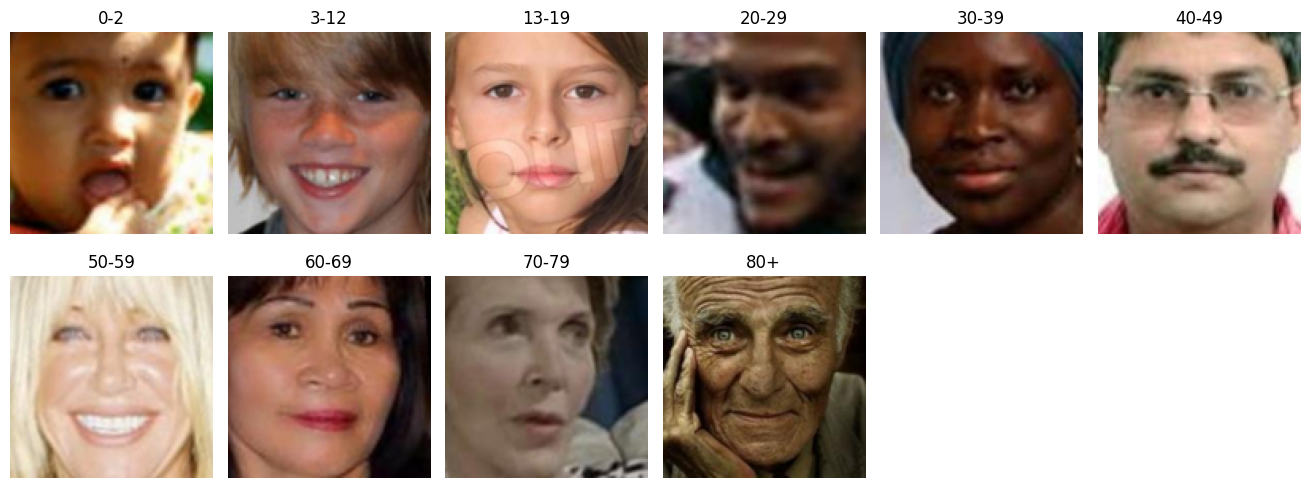

In [11]:
def show_examples(df, by="age_bin", n=12, seed=42, img_size=128):
    rnd = random.Random(seed)
    groups = df.groupby(by, observed=True)
    keys = [k for k,_ in groups]
    keys = [k for k in keys if pd.notna(k)]
    keys = sorted(keys, key=lambda x: labels.index(str(x)) if str(x) in labels else 999)

    picked=[]
    for k in keys:
        g = groups.get_group(k)
        fp = rnd.choice(g["path"].tolist())
        picked.append((k, fp))

    if not picked:
        print("Нет данных для отображения")
        return

    cols = min(6, len(picked))
    rows = math.ceil(len(picked)/cols)
    plt.figure(figsize=(cols*2.2, rows*2.6))
    for i,(k,fp) in enumerate(picked):
        ax = plt.subplot(rows, cols, i+1)
        try:
            img = Image.open(fp).convert("RGB").resize((img_size,img_size))
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5,0.5,str(e),ha="center",va="center")
        ax.set_title(str(k))
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(df, by="age_bin")

## 6) Train/Val split: что важно

Обычно для UTKFace достаточно:
- random split, но **стратифицировать по age_bin**, чтобы в val не исчезли редкие возраста;
- зафиксировать seed;
- отдельно следить за метриками по bin (и по gender/race, если это критично).

**Важно:** возможны почти-dup / серии с одной персоной. Идеально — split по identity, но в UTKFace identity нет, поэтому хотя бы проверяем near-duplicates (опционально).


In [12]:
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["age_bin"]
)
train_df.shape, val_df.shape, train_df["age_bin"].value_counts().min(), val_df["age_bin"].value_counts().min()

((18962, 6), (4741, 6), 539, 134)

## 7) Метрики

### Основная: RMSE (Root Mean Squared Error)

Почему “RMSE forever”:
- возраст — **непрерывная** величина → это регрессия;
- RMSE сильнее штрафует большие ошибки (например, *ребёнка* предсказать как 30 — это очень плохо).

\[
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2}
\]

### Дополнительные (для отчёта и дебага)
- **MAE**: \(\frac{1}{n}\sum |y-\hat y|\) — легче интерпретировать (в “годах”).
- **Accuracy@k**: доля примеров, где \(|y-\hat y|\le k\) (обычно k=5 или 10).
- **Age-bin accuracy + Confusion Matrix**: переводим возраст в группы и смотрим, где именно модель путается (kids vs teens и т.п.).


In [13]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def acc_at_k(y_true, y_pred, k=5):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) <= k))

def to_bin(a):
    # a can be scalar or array
    return pd.cut(pd.Series(a), bins=bins, right=False, labels=labels).astype(str).values

def plot_confmat(y_true_bin, y_pred_bin, title="Confusion matrix"):
    cm = confusion_matrix(y_true_bin, y_pred_bin, labels=labels)
    plt.figure(figsize=(8,6))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred"); plt.ylabel("true")
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    return cm

### Бейзлайн 0: “предсказываем средний возраст”

Это не про качество, а про **минимальную точку отсчёта**: насколько вообще сложна задача по сравнению с тривиальным предиктором.


In [14]:
y_tr = train_df["age"].values
y_va = val_df["age"].values

pred_mean = np.full_like(y_va, fill_value=y_tr.mean(), dtype=float)

metrics = {
    "RMSE": rmse(y_va, pred_mean),
    "MAE": mae(y_va, pred_mean),
    "Acc@5": acc_at_k(y_va, pred_mean, k=5),
    "Acc@10": acc_at_k(y_va, pred_mean, k=10),
}
metrics

{'RMSE': 19.826865871751586,
 'MAE': 15.289226206050577,
 'Acc@5': 0.20396540814174224,
 'Acc@10': 0.492723054207973}

## 8) Какие возрастные группы “похожи” и будут путаться?

На этой стадии можно сделать честную, но простую вещь:
- взять **типичный уровень ошибки** (например, RMSE ~ 7 лет — часто встречается в базовых Kaggle-решениях на UTKFace),
- смоделировать предсказание как `y_pred = y_true + N(0, σ^2)` и посмотреть confusion matrix по age-bins.

Это не заменяет реальную модель, но даёт быстрый ответ:
- **где границы групп самые проблемные**,
- какие bins будут чаще переходить друг в друга при разумном уровне ошибки.


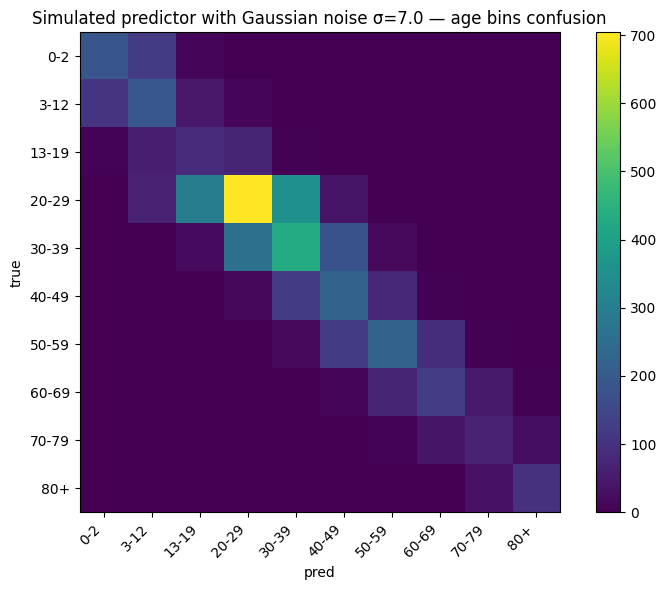

In [15]:
sigma = 7.0  # можно менять (идея: соответствует "типичному" RMSE)
rng = np.random.default_rng(42)

sim_pred = y_va + rng.normal(0, sigma, size=len(y_va))
sim_pred = np.clip(sim_pred, 0, 116)

sim_bin = to_bin(sim_pred)
true_bin = val_df["age_bin"].astype(str).values
_ = plot_confmat(true_bin, sim_bin, title=f"Simulated predictor with Gaussian noise σ={sigma} — age bins confusion")

### Ошибка по возрастным группам (ожидаемая)

Для моделей на UTKFace часто наблюдается:
- лучше на “массовых” возрастах (20–50),
- хуже на редких и быстро меняющихся (дети/подростки) и на хвостах (80+).

Сейчас посчитаем на симуляции, чтобы увидеть “форму” проблемы.


In [16]:
tmp = val_df.copy()
tmp["pred_sim"] = sim_pred
tmp["abs_err"] = np.abs(tmp["age"] - tmp["pred_sim"])
tmp["sq_err"] = (tmp["age"] - tmp["pred_sim"])**2

by = tmp.groupby("age_bin", observed=True).agg(
    n=("age","size"),
    mae=("abs_err","mean"),
    rmse=("sq_err", lambda x: float(np.sqrt(np.mean(x)))),
).reindex(labels)

by

,n,mae,rmse
age_bin,,,
0-2,321,3.240684,4.608060
3-12,362,4.603717,5.874011
13-19,236,5.551529,6.866320
20-29,1469,5.803916,7.254492
30-39,907,5.475479,6.936250
40-49,449,5.175745,6.551195
50-59,460,5.660527,7.131843
60-69,263,5.537552,7.033226
70-79,140,5.722659,7.280839


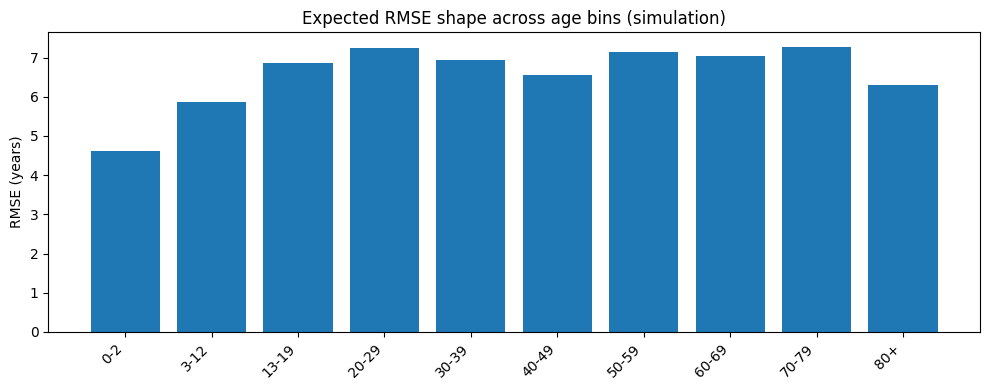

In [17]:
plt.figure(figsize=(10,4))
plt.bar(range(len(labels)), by["rmse"].values)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.title("Expected RMSE shape across age bins (simulation)")
plt.ylabel("RMSE (years)")
plt.tight_layout()
plt.show()

## 9) Предварительные выводы 

### 1) Дисбаланс по возрасту
**Проблема:** модель “тянет” прогноз к 20–40 (где много данных), редкие возраста учатся плохо.  
**Лечение:**
- стратифицированный split по age_bin;
- **re-weighting**: веса в loss по обратной частоте age_bin;
- **oversampling** редких bin / balanced batch sampler;
- мониторинг метрик **по bin**, а не только общая RMSE.

### 2) Шум в лейбле возраста
**Проблема:** возраст по фото субъективен, “похожие” лица могут отличаться на 5–10 лет.  
**Лечение:**
- более робастный loss: **Huber / SmoothL1** вместо чистого MSE;
- предсказывать **ожидаемое значение + дисперсию** (uncertainty), если хочется глубже;
- как альтернатива: **ordinal regression / age-bins classification** (и потом переводить в годы).

### 3) Границы групп (kids/teens) и хвосты (80+)
**Проблема:** именно там чаще всего будут большие ошибки и путаница.  
**Лечение:**
- аугментации + больше данных (если можно);
- отдельный мониторинг: RMSE/MAE по bins, confusion matrix;
- возможно, сделать “двухуровневую” постановку: сначала bin, потом регрессия внутри.

### 4) Bias / fairness (gender/race)
**Проблема:** распределения могут быть перекошены, и качество по подгруппам будет разным.  
**Лечение:**
- мониторинг метрик по подгруппам;
- если задача “продуктовая” — определить, что допустимо использовать и что нет.

### 5) Проблемы данных: качество, окклюзии, разные условия съёмки
**Лечение:**
- сильные аугментации (blur, JPEG, lighting, crop/resize);
- использование предобученных backbone (ResNet/EfficientNet/MobileNet) и fine-tune.



## 10) Бейзлайн 1: transfer learning + regression

Идея baseline:

- берём **pretrained ResNet18**
- меняем последний слой на один нейрон
- решаем задачу как **регрессию возраста**
- считаем **RMSE / MAE** на `val`


In [18]:
import copy
import time

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [19]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
EPOCHS_HEAD = 3
EPOCHS_FT = 7

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [20]:
class AgeDataset(Dataset):
    def __init__(self, frame, tfms=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.tfms = tfms

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        if self.tfms is not None:
            img = self.tfms(img)
        age = torch.tensor(float(row["age"]), dtype=torch.float32)
        return img, age

train_ds = AgeDataset(train_df, train_tfms)
val_ds = AgeDataset(val_df, val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

len(train_ds), len(val_ds)

(18962, 4741)

In [21]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, 1)
)
model = model.to(device)

criterion = nn.SmoothL1Loss(beta=5.0)
model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 234MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
def predict_loader(model, loader):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            out = model(x).squeeze(1).cpu().numpy()
            out = np.clip(out, 0, 116)
            preds.append(out)
            trues.append(y.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return trues, preds

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_n = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(x).squeeze(1)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / total_n

def evaluate(model, loader):
    y_true, y_pred = predict_loader(model, loader)
    return {
        "rmse": rmse(y_true, y_pred),
        "mae": mae(y_true, y_pred)
    }, y_true, y_pred

def fit_model(model, train_loader, val_loader, optimizer, epochs, stage_name="stage", patience=3):
    best_rmse = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    history = []
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer)
        val_metrics, _, _ = evaluate(model, val_loader)

        row = {
            "stage": stage_name,
            "epoch": epoch,
            "train_loss": tr_loss,
            "val_rmse": val_metrics["rmse"],
            "val_mae": val_metrics["mae"],
        }
        history.append(row)
        print(row)

        if val_metrics["rmse"] < best_rmse:
            best_rmse = val_metrics["rmse"]
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("early stop")
            break

    model.load_state_dict(best_state)
    return history

In [23]:
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
hist1 = fit_model(model, train_loader, val_loader, optimizer, EPOCHS_HEAD, stage_name="head", patience=2)

{'stage': 'head', 'epoch': 1, 'train_loss': 13.905369588411153, 'val_rmse': 18.805144332579335, 'val_mae': 13.840922355651855}
{'stage': 'head', 'epoch': 2, 'train_loss': 11.224347041737316, 'val_rmse': 17.46978767602264, 'val_mae': 12.956262588500977}
{'stage': 'head', 'epoch': 3, 'train_loss': 10.558633278548095, 'val_rmse': 16.58338618948994, 'val_mae': 12.380460739135742}


In [24]:
for p in model.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
hist2 = fit_model(model, train_loader, val_loader, optimizer, EPOCHS_FT, stage_name="finetune", patience=3)

{'stage': 'finetune', 'epoch': 1, 'train_loss': 5.332199701665889, 'val_rmse': 8.90517100440389, 'val_mae': 6.281304359436035}
{'stage': 'finetune', 'epoch': 2, 'train_loss': 3.9819495992788267, 'val_rmse': 8.209852152339971, 'val_mae': 5.773481369018555}
{'stage': 'finetune', 'epoch': 3, 'train_loss': 3.6287880222224795, 'val_rmse': 8.338793478949476, 'val_mae': 6.042891979217529}
{'stage': 'finetune', 'epoch': 4, 'train_loss': 3.4600249607720692, 'val_rmse': 7.379631269387322, 'val_mae': 5.195928573608398}
{'stage': 'finetune', 'epoch': 5, 'train_loss': 3.1984012992733355, 'val_rmse': 8.061736314667366, 'val_mae': 5.676342487335205}
{'stage': 'finetune', 'epoch': 6, 'train_loss': 3.0331003067677265, 'val_rmse': 7.45283632499127, 'val_mae': 5.295140743255615}
{'stage': 'finetune', 'epoch': 7, 'train_loss': 2.9118194909755117, 'val_rmse': 7.446969295261685, 'val_mae': 5.221206188201904}
early stop


In [25]:
history = pd.DataFrame(hist1 + hist2)
history

,stage,epoch,train_loss,val_rmse,val_mae
0,head,1,13.905370,18.805144,13.840922
1,head,2,11.224347,17.469788,12.956263
2,head,3,10.558633,16.583386,12.380461
3,finetune,1,5.332200,8.905171,6.281304
4,finetune,2,3.981950,8.209852,5.773481
5,finetune,3,3.628788,8.338793,6.042892
6,finetune,4,3.460025,7.379631,5.195929
7,finetune,5,3.198401,8.061736,5.676342
8,finetune,6,3.033100,7.452836,5.295141
9,finetune,7,2.911819,7.446969,5.221206


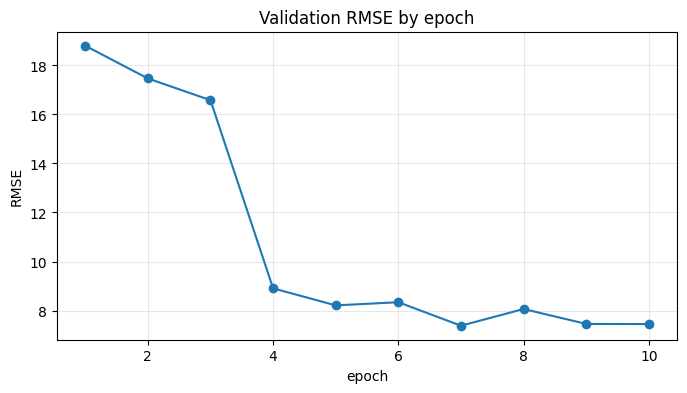

In [26]:
plt.figure(figsize=(8,4))
plt.plot(history.index + 1, history["val_rmse"], marker="o")
plt.title("Validation RMSE by epoch")
plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
val_metrics, y_true, y_pred = evaluate(model, val_loader)
val_metrics

{'rmse': 7.379631269387322, 'mae': 5.195928573608398}

### Сравнение с тривиальным baseline

In [28]:
baseline_mean_rmse = metrics["RMSE"]
baseline_mean_mae = metrics["MAE"]

comparison = pd.DataFrame([
    {"model": "mean_baseline", "rmse": baseline_mean_rmse, "mae": baseline_mean_mae},
    {"model": "resnet18_regression", "rmse": val_metrics["rmse"], "mae": val_metrics["mae"]},
])
comparison

,model,rmse,mae
0,mean_baseline,19.826866,15.289226
1,resnet18_regression,7.379631,5.195929


### Ошибка по возрастным группам

In [29]:
pred_df = val_df.copy().reset_index(drop=True)
pred_df["pred_age"] = y_pred
pred_df["abs_err"] = np.abs(pred_df["age"] - pred_df["pred_age"])
pred_df["sq_err"] = (pred_df["age"] - pred_df["pred_age"])**2

by_bin_real = pred_df.groupby("age_bin", observed=True).agg(
    n=("age", "size"),
    mae=("abs_err", "mean"),
    rmse=("sq_err", lambda s: float(np.sqrt(np.mean(s))))
).reindex(labels)

by_bin_real

,n,mae,rmse
age_bin,,,
0-2,321,1.406215,3.953620
3-12,362,3.000960,5.705535
13-19,236,4.968535,6.118319
20-29,1469,3.888077,5.512946
30-39,907,5.539524,6.915767
40-49,449,6.600747,8.128634
50-59,460,7.522188,9.802510
60-69,263,8.224505,10.752844
70-79,140,8.467042,10.870633


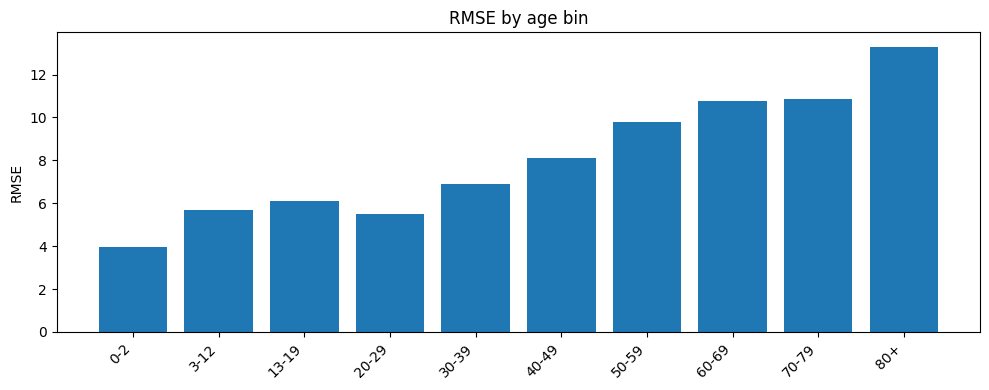

In [30]:
plt.figure(figsize=(10,4))
plt.bar(range(len(labels)), by_bin_real["rmse"].fillna(0).values)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.title("RMSE by age bin")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()